Shape: (100000, 32)

FELT RESTED RF Accuracy: 0.73555
FELT RESTED XGB Accuracy: 0.7406
FELT RESTED XGB AUC: 0.8236619647893832

RISK XGB Accuracy: 0.94795
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     10831
           1       0.96      0.93      0.94      6696
           2       0.69      0.80      0.74      1660
           3       0.84      0.80      0.82       813

    accuracy                           0.95     20000
   macro avg       0.87      0.88      0.87     20000
weighted avg       0.95      0.95      0.95     20000



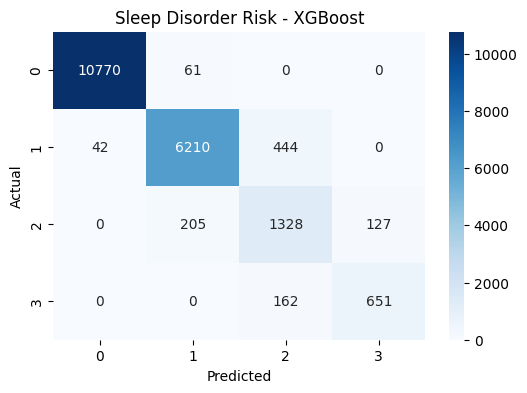

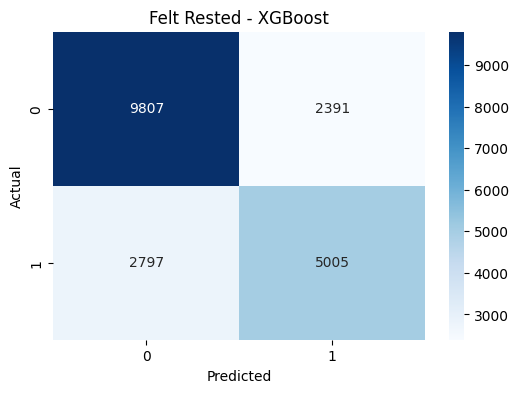

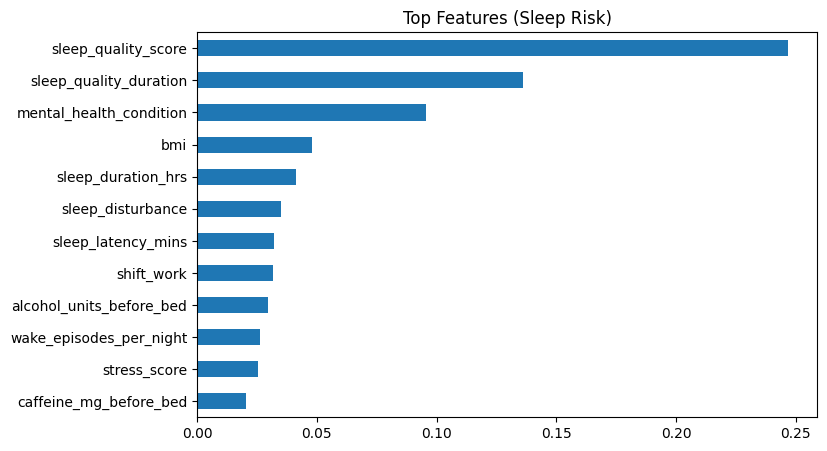

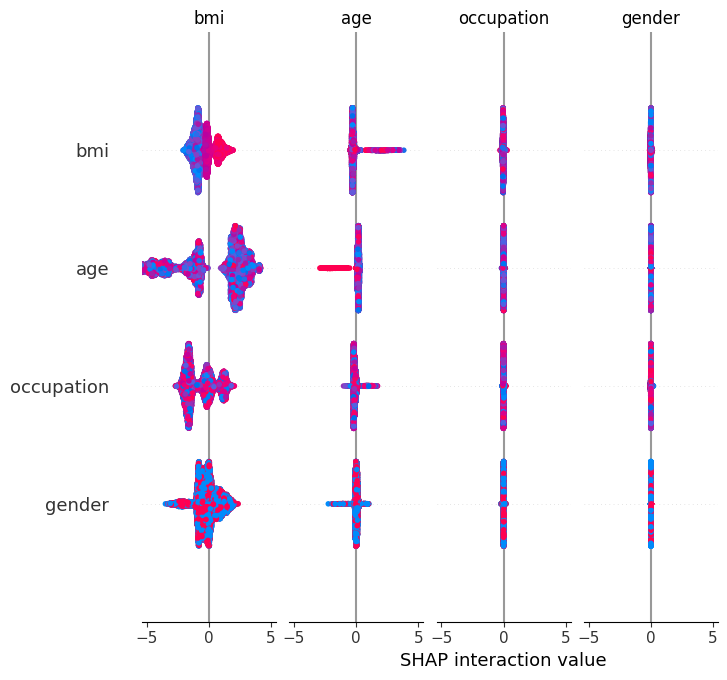


Recommendations: ['Improve sleep consistency.']


['D_xgb_felt_model.pkl']

In [ ]:
# =========================
# 1. IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
import shap

# =========================
# 2. LOAD DATASET
# =========================
url = "https://raw.githubusercontent.com/mohan13krishna/Sleep-Health-Daily-Performance-Dataset/main/sleep_health_dataset.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)

# =========================
# 3. FEATURE ENGINEERING
# =========================

df["sleep_efficiency"] = df["deep_sleep_percentage"] + df["rem_percentage"]

df["sleep_disturbance"] = df["wake_episodes_per_night"] * df["sleep_latency_mins"]

df["stress_workload"] = df["stress_score"] * df["work_hours_that_day"]

df["screen_caffeine"] = df["screen_time_before_bed_mins"] * df["caffeine_mg_before_bed"]

df["sleep_quality_duration"] = df["sleep_quality_score"] * df["sleep_duration_hrs"]

# =========================
# 4. SPLIT FEATURES / TARGETS
# =========================
X = df.drop(
    ["person_id", "felt_rested", "sleep_disorder_risk", "cognitive_performance_score"],
    axis=1
)

y_felt = df["felt_rested"]
y_risk = df["sleep_disorder_risk"]

# =========================
# 5. ENCODING FEATURES
# =========================
X_encoded = X.copy()
encoders = {}

for col in X_encoded.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col])
    encoders[col] = le

# =========================
# 6. ENCODE TARGETS
# =========================
felt_encoder = LabelEncoder()
y_felt_enc = felt_encoder.fit_transform(y_felt)

risk_encoder = LabelEncoder()
y_risk_enc = risk_encoder.fit_transform(y_risk)

# =========================================================
# ============== FELT RESTED MODEL =========================
# =========================================================

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_encoded, y_felt_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_felt_enc
)

# Random Forest
rf_felt = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)
rf_felt.fit(X_train_f, y_train_f)

pred_felt_rf = rf_felt.predict(X_test_f)

print("\nFELT RESTED RF Accuracy:", accuracy_score(y_test_f, pred_felt_rf))

# XGBoost
xgb_felt = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_felt.fit(X_train_f, y_train_f)

pred_felt_xgb = xgb_felt.predict(X_test_f)

print("FELT RESTED XGB Accuracy:", accuracy_score(y_test_f, pred_felt_xgb))

# AUC
prob_felt = xgb_felt.predict_proba(X_test_f)[:, 1]
auc_felt = roc_auc_score(y_test_f, prob_felt)

print("FELT RESTED XGB AUC:", auc_felt)

# =========================================================
# ============== SLEEP DISORDER RISK MODEL ===============
# =========================================================

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_encoded, y_risk_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_risk_enc
)

# sample weights (IMPORTANT FIX)
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_r
)

# XGBoost (Improved)
xgb_risk = XGBClassifier(
    objective="multi:softprob",
    num_class=len(risk_encoder.classes_),
    n_estimators=600,
    max_depth=8,
    learning_rate=0.03,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_risk.fit(
    X_train_r,
    y_train_r,
    sample_weight=sample_weights
)

pred_risk_xgb = xgb_risk.predict(X_test_r)

print("\nRISK XGB Accuracy:", accuracy_score(y_test_r, pred_risk_xgb))
print(classification_report(y_test_r, pred_risk_xgb))

# =========================================================
# ================= CONFUSION MATRIX ======================
# =========================================================

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test_r, pred_risk_xgb, "Sleep Disorder Risk - XGBoost")
plot_cm(y_test_f, pred_felt_xgb, "Felt Rested - XGBoost")

# =========================================================
# ================= FEATURE IMPORTANCE ====================
# =========================================================

feat_imp = pd.Series(
    xgb_risk.feature_importances_,
    index=X_encoded.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(12).plot(kind="barh")
plt.title("Top Features (Sleep Risk)")
plt.gca().invert_yaxis()
plt.show()

# =========================================================
# ===================== SHAP ==============================
# =========================================================

explainer = shap.TreeExplainer(xgb_risk)
shap_values = explainer.shap_values(X_test_r)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_r)
else:
    shap.summary_plot(shap_values, X_test_r)

# =========================================================
# ============== PERSONALIZED RECOMMENDER ================
# =========================================================

def generate_recommendation(sample):
    rec = []

    if sample["stress_score"] > 7:
        rec.append("Reduce stress (meditation / breathing).")

    if sample["screen_time_before_bed_mins"] > 90:
        rec.append("Reduce screen time before sleep.")

    if sample["sleep_duration_hrs"] < 7:
        rec.append("Increase sleep duration (7–8 hrs).")

    if sample["wake_episodes_per_night"] > 3:
        rec.append("Improve sleep consistency.")

    if sample["caffeine_mg_before_bed"] > 100:
        rec.append("Avoid caffeine before bed.")

    return rec


sample = X_test_r.iloc[0].to_dict()
print("\nRecommendations:", generate_recommendation(sample))


# =========================
# SAVE MODELS
# =========================
import joblib

# =========================
# A) MAIN MODEL
# =========================
joblib.dump(xgb_risk, "A_xgb_risk_model.pkl")


# =========================
# B) ENCODERS
# =========================
joblib.dump(encoders, "B_label_encoders.pkl")
joblib.dump(risk_encoder, "B_risk_encoder.pkl")


# =========================
# C) FEATURE COLUMNS (IMPORTANT)
# =========================
joblib.dump(list(X_encoded.columns), "C_feature_columns.pkl")


# =========================
# D) OPTIONAL MODEL (Felt Rested)
# =========================
joblib.dump(xgb_felt, "D_xgb_felt_model.pkl")